In [1]:
import sys
import os.path
import numpy as np  
import uproot  
import awkward as ak  
import atlasopenmagic as atom  
import requests 
import time  
import warnings
import pandas as pd
import matplotlib.pyplot as plt
# bringing in the usual tools for arrays, dataframes, and plotting

from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_curve, auc
import matplotlib.gridspec as gridspec
from sklearn.inspection import permutation_importance
# pulling in the machine learning stuff we need for the BDT

# grabbing the right ATLAS open data release
atom.set_release('2025e-13tev-beta')
lumi = 36600 # setting the luminosity (how much data we actually collected)

# using the whole dataset for the final thesis results
fraction = 1.0

Fetching metadata for release: 2025e-13tev-beta...
Fetching datasets: 100%|██████████| 374/374 [00:00<00:00, 869.86datasets/s]
✓ Successfully cached 374 datasets.
Active release: 2025e-13tev-beta. (Datasets path: REMOTE)


In [2]:
# grouping all the physics processes by their dataset IDs
mc_defs = {
    r'Signal':    {'dids': [700601],}, # the main thing we are looking for
    r'Diboson':   {'dids': [700493,700488,700492,700600],}, # the backgrounds we have to deal with
    r'Vjets':     {'dids': [700323,700324,700325,700470,700320,700321,700322,
                            700792,700793,700794,700341,700342,700343,700344,
                            700345,700346,700347,700348,700349,700338,700339,700340],},
    r'other':     {'dids': [410470,410644,410645,410658,410659,601355,601352],},
}

# putting together the monte carlo simulation files
mc_samples = atom.build_mc_dataset(mc_defs, skim='exactly3lep', protocol='https')
# getting the actual real collision data
data_samples = atom.build_data_dataset("exactly3lep", name="Data", protocol='https')
# smashing them all into one big dictionary so it's easier to handle
samples = {**data_samples, **mc_samples}

/tmp/ipykernel_23030/549107601.py:12: DeprecationWarning: The build_mc_dataset function is deprecated. Use build_dataset with the appropriate MC definitions instead.
  mc_samples = atom.build_mc_dataset(mc_defs, skim='exactly3lep', protocol='https')
/tmp/ipykernel_23030/549107601.py:14: DeprecationWarning: The build_data_dataset function is deprecated. Use build_dataset with the appropriate data definitions instead.
  data_samples = atom.build_data_dataset("exactly3lep", name="Data", protocol='https')


In [3]:
def get_event_sf(sf_array):
    """Helper function to extract Scale Factors (SF) for Awkward Arrays."""
    # multiplying the scale factors together if there's more than one per event
    return ak.prod(sf_array, axis=1) if sf_array.ndim > 1 else sf_array

def calc_weight(data):
    """Calculates the total event weight using cross-sections and ATLAS Scale Factors."""
    # mixing together all the detector and trigger efficiencies
    sf = get_event_sf(data["ScaleFactor_ELE"]) * get_event_sf(data["ScaleFactor_MUON"]) * \
         data["ScaleFactor_PILEUP"] * data["ScaleFactor_MLTRIGGER"]
    
    # normalizing things so our theory matches the reality of the detector
    norm = (data["xsec"] * data["kfac"] * data["filteff"]) / data["sum_of_weights"]
    
    # spitting out the final weight for the event
    return data["mcWeight"] * sf * norm * lumi

def find_vars(data):
    """Reconstructs the Z and W boson kinematics from the 3 leptons."""
    # packing up the basic physical traits for each lepton
    leptons = ak.zip({
        "pt": data.lep_pt, "phi": data.lep_phi, "type": data.lep_type, "charge": data.lep_charge, "E": data.lep_e,
        "px": data.lep_pt * np.cos(data.lep_phi), "py": data.lep_pt * np.sin(data.lep_phi),
        "pz": data.lep_pt / np.tan(2.0 * np.arctan(np.exp(-data.lep_eta))),
    })
    
    # making every possible pair of two leptons
    pairs = ak.combinations(leptons, 2, fields=["l1", "l2"])
    # keeping only pairs that make sense for a Z boson (same flavor, opposite charge)
    sfos = (pairs.l1.type == pairs.l2.type) & (pairs.l1.charge != pairs.l2.charge)
    
    # doing the math to find the mass of those pairs
    m_ll = np.sqrt(np.maximum((pairs[sfos].l1.E + pairs[sfos].l2.E)**2 - 
                             ((pairs[sfos].l1.px + pairs[sfos].l2.px)**2 + 
                              (pairs[sfos].l1.py + pairs[sfos].l2.py)**2 + 
                              (pairs[sfos].l1.pz + pairs[sfos].l2.pz)**2), 0))
    
    # picking the pair that is closest to the real Z mass
    best = ak.argmin(np.abs(m_ll - 91.18), axis=1, keepdims=True)
    z_m = ak.firsts(m_ll[best])
    z_l1_pt, z_l2_pt = ak.firsts(pairs[sfos][best].l1.pt), ak.firsts(pairs[sfos][best].l2.pt)
    
    # leaving the odd one out to be our W boson lepton
    w_lep = ak.firsts(leptons[(np.abs(leptons.pt - z_l1_pt) > 0.001) & (np.abs(leptons.pt - z_l2_pt) > 0.001)])
    # calculating the transverse mass for the W using the missing energy
    w_mt = np.sqrt(2 * w_lep.pt * data.met * (1 - np.cos(w_lep.phi - data.met_phi)))
    
    # giving back the final variables we need for the BDT
    return z_m, w_mt

In [4]:
# telling the script exactly which pieces of information we need from the big files
variables = [
    "mcWeight", "sum_of_weights", "ScaleFactor_ELE", "ScaleFactor_MUON", "ScaleFactor_MLTRIGGER", 
    "ScaleFactor_PILEUP", "xsec", "filteff", "kfac", "lep_n", "lep_pt", "lep_eta", "lep_phi", 
    "lep_charge", "lep_type", "met", "met_phi", "lep_e", "lep_isTightID", 
    "lep_ptvarcone30", "lep_z0", "lep_d0sig"
]

# setting up an empty basket to hold our data pieces as we process them
all_chunks = []
print("Starting data extraction loop...")

# looping through each type of physics event we defined earlier
for s_name, s_info in samples.items():
    print(f"Reading {s_name}...")
    
    # going through the web links for the data files
    for url in s_info['list']:
        local_fn = url.replace("simplecache::", "").split("/")[-1]
        
        # checking if we already downloaded the file, and grabbing it if we haven't
        if not os.path.exists(local_fn):
            with open(local_fn, "wb") as f: f.write(requests.get(url.replace("simplecache::", "")).content)
            
        # cracking open the file and reading it in manageable chunks so we don't crash the computer
        with uproot.open(local_fn + ":analysis") as tree:
            for data in tree.iterate(variables, library="ak", entry_stop=tree.num_entries * fraction):
                
                # throwing out the junk data to only keep the "good" leptons
                # making sure the detector is really confident it saw a lepton
                tight_mask = ak.all(data.lep_isTightID, axis=1)
                # checking that the lepton is isolated and not swimming in a mess of other particles
                iso_mask = ak.all(data.lep_ptvarcone30 / data.lep_pt < 0.08, axis=1)
                # making sure the particles actually came from the main collision point
                z0_mask = ak.all(np.abs(data.lep_z0) < 0.5, axis=1)
                d0_mask = ak.all(np.abs(data.lep_d0sig) < 3.0, axis=1)
                
                # strictly keeping only events that have exactly three of these high-quality leptons
                data = data[(data.lep_n == 3) & tight_mask & iso_mask & z0_mask & d0_mask]
                
                # skipping to the next chunk if nothing survived our strict cuts
                if len(data) == 0: continue
                
                # trying to piece together the original Z and W bosons using our helper function
                z_m, w_mt = find_vars(data)
                
                # dropping the events where the math didn't work out to form those bosons
                valid = ~ak.is_none(z_m) & ~ak.is_none(w_mt)
                n_events = ak.sum(valid)
                if n_events == 0: continue
                
                # scaling the monte carlo simulations so they accurately reflect the real world
                if s_name != 'Data':
                    wts = ak.to_numpy(calc_weight(data[valid])).flatten()
                    
                    # bumping up the Vjets background a bit because the simulation usually underestimates fake leptons here
                    if s_name == 'Vjets':
                        wts = wts * 1.35 
                else:
                    # giving real data a weight of exactly 1, since it's already real
                    wts = np.ones(n_events)

                # packing all our surviving, clean data into a neat dataframe so the machine learning model can easily digest it
                df_c = pd.DataFrame({
                    'lep_pt_1': ak.to_numpy(data.lep_pt[valid, 0]).flatten(),
                    'lep_pt_2': ak.to_numpy(data.lep_pt[valid, 1]).flatten(),
                    'lep_pt_3': ak.to_numpy(data.lep_pt[valid, 2]).flatten(),
                    'met': ak.to_numpy(data.met[valid]).flatten(),
                    'zmass': ak.to_numpy(z_m[valid]).flatten(),
                    'wmt': ak.to_numpy(w_mt[valid]).flatten(),
                    'weight': wts,
                    'is_sig': np.full(n_events, 1 if s_name == 'Signal' else 0),
                    'is_data': np.full(n_events, 1 if s_name == 'Data' else 0),
                    'sample_group': np.full(n_events, s_name)
                })
                
                # tossing this finished chunk into our main basket
                all_chunks.append(df_c)

# gluing all the chunks together into one massive, final table
df = pd.concat(all_chunks, ignore_index=True)
print("Data loading complete.")

Starting data extraction loop...
Reading Data...
Reading Signal...
Reading Diboson...
Reading Vjets...
Reading other...
Data loading complete.


In [ ]:
# leaving out angles like eta because earlier tests showed they weren't really helping
features = ['lep_pt_1', 'lep_pt_2', 'lep_pt_3', 'met', 'zmass', 'wmt']

# sweeping away any broken or missing data rows just to be safe
df = df.dropna(subset=features + ['weight', 'is_sig'])
# pulling out only the simulated events since we don't train on real collision data
df_mc = df[df.is_data == 0]

# slicing the data so we have 70% to teach the model and 30% to quiz it later
X_train, X_test, y_train, y_test, w_train, w_test = train_test_split(
    df_mc[features], df_mc.is_sig, df_mc.weight, test_size=0.3, random_state=42
)

# forcing the total weights of the signal and the background to be equal 
# doing this so the model dont't just learn to always guess more common background events, and ignore the signal events
sig_mask, bkg_mask = (y_train == 1), (y_train == 0)
w_train_ml = np.copy(w_train)
w_train_ml[sig_mask] = w_train[sig_mask] * (1000.0 / np.sum(w_train[sig_mask]))
w_train_ml[bkg_mask] = w_train[bkg_mask] * (1000.0 / np.sum(w_train[bkg_mask]))

# rules for setting our model
bdt = HistGradientBoostingClassifier(
    max_iter=200,          # giving it 200 tries to learn the patterns
    max_depth=3,           # keeping the decision trees shallow so it doesn't overthink things
    learning_rate=0.05,    # making it learn slowly and carefully
    verbose=1,
    random_state=42
)

print(f"Training BDT on {len(X_train)} events...")
# actually letting the model loose on the training data
bdt.fit(X_train, y_train, sample_weight=w_train_ml)
print("Training successful!")

# pulling the final probability numbers from the model to see how well it tells the difference between signal and background
df['bdt_score'] = bdt.predict_proba(df[features])[:, 1]
y_train_pred = bdt.predict_proba(X_train)[:, 1]
y_test_pred = bdt.predict_proba(X_test)[:, 1]

Training BDT on 88123 events...
Binning 0.004 GB of training data: 0.037 s
Binning 0.000 GB of validation data: 0.002 s
Fitting gradient boosted rounds:
Fit 117 trees in 0.440 s, (926 total leaves)
Time spent computing histograms: 0.082s
Time spent finding best splits:  0.035s
Time spent applying splits:      0.059s
Time spent predicting:           0.022s
Training successful!


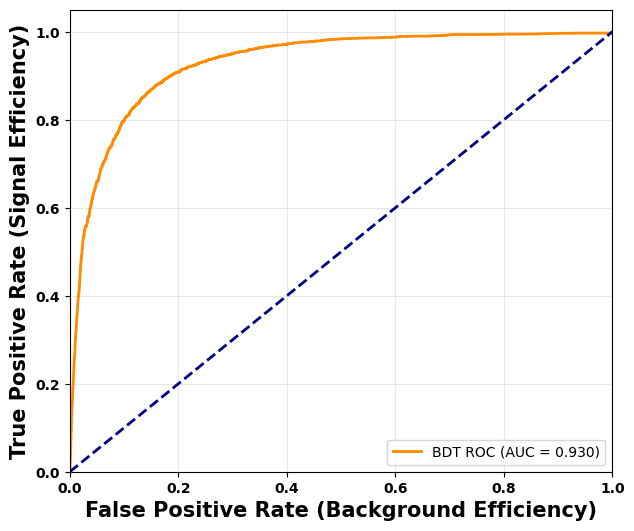

In [13]:
# setting up the blank canvas for our graph
plt.figure(figsize=(7, 6))

# crunching the numbers to see how often the model is right (true positives) versus how often it gets fooled (false positives)
fpr, tpr, _ = roc_curve(y_test, y_test_pred, sample_weight=np.abs(w_test))

# sorting the points in order so the math for the area under the curve doesn't trip over itself
idx = np.argsort(fpr)
fpr, tpr = fpr[idx], tpr[idx]
# calculating that final overall discriminant that tells us how good the model really is
roc_auc = auc(fpr, tpr)

# drawing the bright orange line to show off our model's actual performance
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'BDT ROC (AUC = {roc_auc:.3f})')
# drawing a dashed line that represents a totally blind guess, just to prove we are doing way better than that
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')

# locking down the borders of the graph so it looks clean
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])

# slapping on some bold labels so people reading your thesis know exactly what they are looking at
plt.xlabel('False Positive Rate (Background Efficiency)', fontsize=15, fontweight='bold')
plt.ylabel('True Positive Rate (Signal Efficiency)', fontsize=15, fontweight='bold')
plt.xticks(fontweight='bold')
plt.yticks(fontweight='bold')

# dropping a legend in the corner and turning on a faint grid before showing the final picture
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

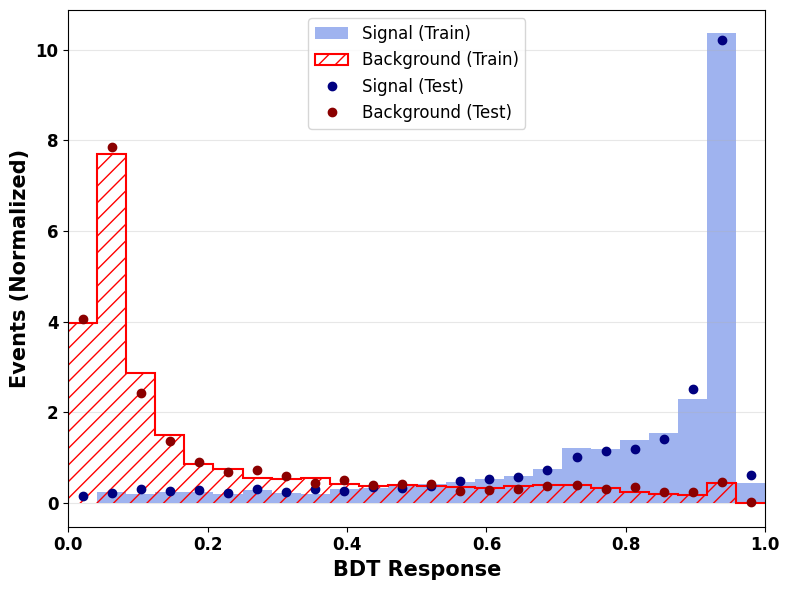

In [ ]:
# checking if the model just memorized the answers instead of actually learning the physics
# if the dots line up nicely with the colored blocks, we are in good shape
plt.figure(figsize=(8, 6))

bins = np.linspace(0, 1, 25)
centers = (bins[:-1] + bins[1:]) / 2

plt.hist(y_train_pred[y_train==1], bins=bins, weights=w_train[y_train==1], density=True, 
         color='royalblue', alpha=0.5, label='Signal (Train)', histtype='stepfilled')
plt.hist(y_train_pred[y_train==0], bins=bins, weights=w_train[y_train==0], density=True, 
         color='red', label='Background (Train)', histtype='step', hatch='//', linewidth=1.5)

# counting up how the model handled the pop quiz on data it had never seen before
hist_sig_test, _ = np.histogram(y_test_pred[y_test==1], bins=bins, weights=w_test[y_test==1], density=True)
hist_bkg_test, _ = np.histogram(y_test_pred[y_test==0], bins=bins, weights=w_test[y_test==0], density=True)

plt.plot(centers, hist_sig_test, 'o', color='navy', label='Signal (Test)')
plt.plot(centers, hist_bkg_test, 'o', color='darkred', label='Background (Test)')

plt.xlabel('BDT Response', fontsize=15, fontweight='bold')
plt.ylabel('Events (Normalized)', fontsize=15, fontweight='bold')
plt.xticks(fontsize=12, fontweight='bold')
plt.yticks(fontsize=12, fontweight='bold')

plt.legend(loc='upper center', fontsize=12) 
plt.grid(axis='y', alpha=0.3)
plt.xlim(0, 1)
plt.tight_layout()
plt.show()

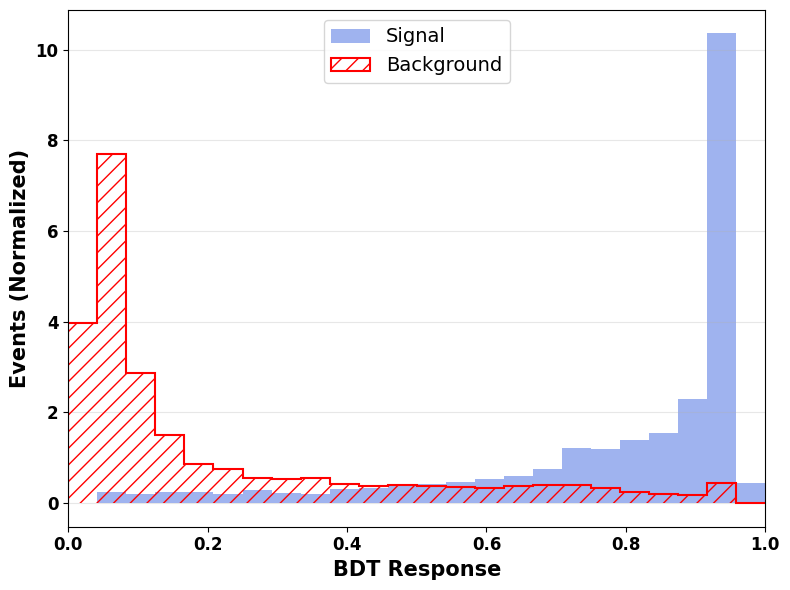

In [16]:
# drawing a picture to see how well the model separates our good signal from the background junk
plt.figure(figsize=(8, 6))

# slicing the bottom axis into 25 neat little buckets between 0 and 1
bins = np.linspace(0, 1, 25) 

# coloring in a soft blue shape to show where our rare signal events ended up
plt.hist(y_train_pred[y_train==1], bins=bins, weights=w_train[y_train==1], density=True, 
         color='royalblue', alpha=0.5, label='Signal', histtype='stepfilled')

# drawing harsh red lines to show where the background noise landed
plt.hist(y_train_pred[y_train==0], bins=bins, weights=w_train[y_train==0], density=True, 
         color='red', label='Background', histtype='step', hatch='//', linewidth=1.5)

# slapping on some bold text for the axes so it's easy to read during your presentation
plt.xlabel('BDT Response', fontsize=15, fontweight='bold')
plt.ylabel('Events (Normalized)', fontsize=15, fontweight='bold')
plt.xticks(fontsize=12, fontweight='bold')
plt.yticks(fontsize=12, fontweight='bold')

# dropping a clean legend at the top and adding some faint horizontal lines in the background
plt.legend(loc='upper center', fontsize=14, frameon=True) 
plt.grid(axis='y', alpha=0.3)
# locking the edges so the graph doesn't wander off
plt.xlim(0, 1)
plt.tight_layout()
plt.show()

In [33]:
# selecting an optimal threshold based on earlier tests to keep events where the model is at least 70% confident it's a signal
bdt_cut = 0.9
df_cut = df[df.bdt_score > bdt_cut]

# counting the raw number of simulated events that survived the cut
raw_sig = len(df_cut[(df_cut.is_sig == 1) & (df_cut.is_data == 0)])
raw_vjets = len(df_cut[(df_cut.sample_group == 'Vjets') & (df_cut.is_data == 0)])
raw_other = len(df_cut[(df_cut.sample_group == 'other') & (df_cut.is_data == 0)])
raw_diboson = len(df_cut[(df_cut.sample_group == 'Diboson') & (df_cut.is_data == 0)])

# applying the physical weights so the simulation matches the reality of the detector
w_sig = df_cut[(df_cut.is_sig == 1) & (df_cut.is_data == 0)].weight.sum()
w_vjets = df_cut[(df_cut.sample_group == 'Vjets') & (df_cut.is_data == 0)].weight.sum()
w_other = df_cut[(df_cut.sample_group == 'other') & (df_cut.is_data == 0)].weight.sum()
w_diboson = df_cut[(df_cut.sample_group == 'Diboson') & (df_cut.is_data == 0)].weight.sum()

# summing up all the expected background events and the total simulated prediction
w_total_bg = w_vjets + w_other + w_diboson
w_total_mc = w_sig + w_total_bg

# counting how many actual real-world collision events passed the selection
data_measured = len(df_cut[df_cut.is_data == 1])

# calculating the statistical uncertainty for our simulated data using the sum of squared weights
err_sig = np.sqrt((df_cut[(df_cut.is_sig == 1) & (df_cut.is_data == 0)].weight ** 2).sum())
err_vjets = np.sqrt((df_cut[(df_cut.sample_group == 'Vjets') & (df_cut.is_data == 0)].weight ** 2).sum())
err_other = np.sqrt((df_cut[(df_cut.sample_group == 'other') & (df_cut.is_data == 0)].weight ** 2).sum())
err_diboson = np.sqrt((df_cut[(df_cut.sample_group == 'Diboson') & (df_cut.is_data == 0)].weight ** 2).sum())

# combining those errors using standard error propagation rules
err_total_bg = np.sqrt(err_vjets**2 + err_other**2 + err_diboson**2)
err_total_mc = np.sqrt(err_sig**2 + err_total_bg**2)
err_data = np.sqrt(data_measured)

# evaluating how well the real data matches the overall simulation, while propagating the error
data_mc_ratio = data_measured / w_total_mc if w_total_mc > 0 else 0
err_data_mc_ratio = data_mc_ratio * np.sqrt((err_data/data_measured)**2 + (err_total_mc/w_total_mc)**2) if data_measured > 0 else 0

# checking how much our signal stands out against the background
sig_bg_ratio = w_sig / w_total_bg if w_total_bg > 0 else 0
err_sig_bg_ratio = sig_bg_ratio * np.sqrt((err_sig/w_sig)**2 + (err_total_bg/w_total_bg)**2) if w_sig > 0 else 0

# calculating the final statistical significance
S = w_sig
B = w_total_bg

if B > 0:
    significance = S / np.sqrt(B)
    # applying partial derivatives for error propagation
    dZ_dS = 1.0 / np.sqrt(B)
    dZ_dB = -S / (2.0 * B**1.5)
    err_significance = np.sqrt((dZ_dS * err_sig)**2 + (dZ_dB * err_total_bg)**2)
else:
    significance = 0
    err_significance = 0

print(f"=== RAW SIMULATED EVENTS (Cut BDT > {bdt_cut}) ===")
print(f"Signal (WZ):           {raw_sig}")
print(f"Background (V+jets):   {raw_vjets}")
print(f"Background (OTHER):    {raw_other}")
print(f"Background (ZZ, WW):   {raw_diboson}")
print("-" * 50)

print(f"=== WEIGHTED EVENTS (Yield ± Stat. Error) ===")
print(f"Signal (WZ):           {w_sig:.2f} ± {err_sig:.2f}")
print(f"Background (V+jets):   {w_vjets:.2f} ± {err_vjets:.2f}")
print(f"Background (OTHER):    {w_other:.2f} ± {err_other:.2f}")
print(f"Background (ZZ, WW):   {w_diboson:.2f} ± {err_diboson:.2f}")
print("-" * 50)

print(f"TOTAL Expected Background: {w_total_bg:.2f} ± {err_total_bg:.2f}")
print(f"TOTAL Expected (Sig + Bg): {w_total_mc:.2f} ± {err_total_mc:.2f}")
print(f"Real Data Measured:        {data_measured} ± {err_data:.2f}")
print("-" * 50)

print(f"Data / Expected (MC) Ratio: {data_mc_ratio:.4f} ± {err_data_mc_ratio:.4f}")
print(f"Signal / Background Ratio:  {sig_bg_ratio:.4f} ± {err_sig_bg_ratio:.4f}")
print(f"Statistical Significance:   {significance:.2f} ± {err_significance:.2f} σ")

=== RAW SIMULATED EVENTS (Cut BDT > 0.9) ===
Signal (WZ):           18059
Background (V+jets):   12182
Background (OTHER):    548
Background (ZZ, WW):   2594
--------------------------------------------------
=== WEIGHTED EVENTS (Yield ± Stat. Error) ===
Signal (WZ):           4946.91 ± 70.98
Background (V+jets):   236.63 ± 56.31
Background (OTHER):    270.30 ± 11.81
Background (ZZ, WW):   314.50 ± 11.53
--------------------------------------------------
TOTAL Expected Background: 821.43 ± 58.68
TOTAL Expected (Sig + Bg): 5768.34 ± 92.09
Real Data Measured:        6310 ± 79.44
--------------------------------------------------
Data / Expected (MC) Ratio: 1.0939 ± 0.0222
Signal / Background Ratio:  6.0223 ± 0.4388
Statistical Significance:   172.60 ± 6.64 σ


Calculating Permutation Feature Importance...


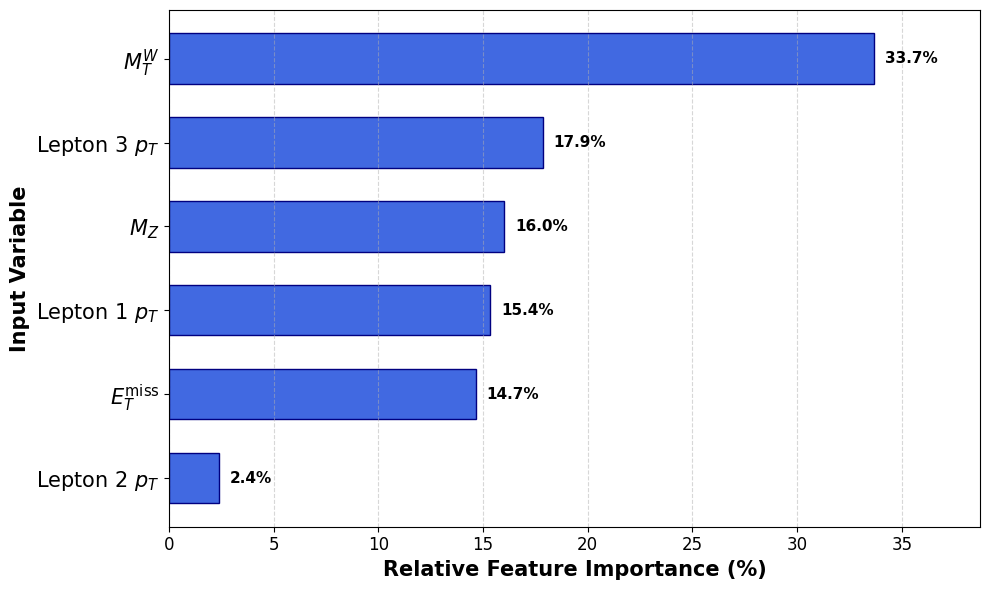

In [25]:
# checking which physical variables actually drove the model's decisions by scrambling them one by one
print("Calculating Permutation Feature Importance...")

# looking at how much the model's performance drops when we shuffle a specific feature
# realizing that a huge drop means the model was relying heavily on that piece of information
result = permutation_importance(
    bdt, X_test, y_test, scoring='roc_auc', 
    n_repeats=5, random_state=42, n_jobs=-1
)

# organizing the features from least to most important so they stack nicely in the graph
sorted_idx = result.importances_mean.argsort()
sorted_features = np.array(features)[sorted_idx]
raw_importances = result.importances_mean[sorted_idx]

# --- NOU: Transformăm importanța brută în procent relativ (Relative Importance %) ---
# Dacă suma totală a scăderilor este 100%, cât la sută reprezintă fiecare variabilă?
sorted_importances_pct = (raw_importances / raw_importances.sum()) * 100

# translating the raw code names into proper mathematical symbols for the final presentation
latex_labels = {
    'wmt': r'$M_T^W$',
    'zmass': r'$M_Z$',
    'met': r'$E_T^{\mathrm{miss}}$',
    'lep_pt_1': r'Lepton 1 $p_T$',
    'lep_pt_2': r'Lepton 2 $p_T$',
    'lep_pt_3': r'Lepton 3 $p_T$'
}

# applying those clean labels to our sorted list
display_features = [latex_labels.get(feat, feat) for feat in sorted_features]

# drawing the horizontal bars to visualize the results
plt.figure(figsize=(10, 6))
bars = plt.barh(display_features, sorted_importances_pct, color='royalblue', edgecolor='navy', height=0.6)

# printing the exact numbers at the end of each bar so the reader doesn't have to guess the values
# --- NOU: Am schimbat formatul textului pentru a afișa 1 zecimală și semnul % ---
for bar in bars:
    # Adăugăm un mic spațiu (de ex. 1% din lățimea maximă) ca să nu se lipească textul de bară
    offset = max(sorted_importances_pct) * 0.015 
    plt.text(bar.get_width() + offset, bar.get_y() + bar.get_height()/2, 
             f'{bar.get_width():.1f}%', 
             va='center', fontsize=11, fontweight='bold', color='black')

# adding bold text and standard labels to keep the formatting academic and clear
plt.xlabel('Relative Feature Importance (%)', fontsize=15, fontweight='bold')
plt.ylabel('Input Variable', fontsize=15, fontweight='bold')
plt.xticks(fontsize=12)
plt.yticks(fontsize=15) 

# stretching the right side of the graph just enough so our text numbers don't get cut off
plt.xlim(0, max(sorted_importances_pct) * 1.15) 
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

In [32]:
#####EXTRA for AMS
if(B>0):  
    ams_score = np.sqrt(2 * ((S + B) * np.log(1 + S/B) - S))
else:
    ams_score = 0

print(f"Standard Significance (S/sqrt(B)): {significance:.2f} σ")
print(f"Exact Poisson AMS:                 {ams_score:.2f} σ")

Standard Significance (S/sqrt(B)): 172.60 σ
Exact Poisson AMS:                 112.22 σ
